# Aileron Design — Cruise-Phase Roll Authority
### Electric V-BAT-Like Tail-Sitter (EDF) — Conceptual Design Study

---

## Purpose

`control_vane_design` (NB3) sizes jet-vane control authority from **hover**
thrust only. Because `q_jet = T / A_disk` scales linearly with thrust
(actuator-disk momentum theory), jet-vane authority collapses in cruise,
where thrust is only a small fraction of hover thrust (set by cruise L/D).
This notebook sizes wing **ailerons** as the primary roll actuator in
wing-borne cruise -- ailerons use wing dynamic pressure instead, which
does not depend on EDF throttle setting.

Jet vanes remain primary for all three axes in hover/transition (where
aero surfaces are ineffective) and stay available as a roll backup in
cruise -- nothing is removed, this notebook only adds a second roll path
where the first one is weakest.

---

## Inputs

- `out/airfoil.yaml` *(from Notebook 2 — wing airfoil, t/c, Oswald e)*
- `out/control_vanes.yaml` *(from Notebook 3 — jet-vane authority, hover
  q_jet, slender-body roll/pitch inertia estimates)*
- `config/aileron.yaml` *(aileron geometry, deflection limits, hardware
  mass)*
- `config/aerodynamics.yaml` *(shared `ddot_min_deg_s2` requirement)*

## Outputs

- `out/aileron.yaml`
- `out/aileron_authority_curves.png`

---

In [1]:
import sys, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import yaml

REPO_ROOT   = Path().resolve().parents[0]
SRC_PATH    = REPO_ROOT / "src"
CONFIG_PATH = REPO_ROOT / "config"
OUT_PATH    = REPO_ROOT / "out"
sys.path.insert(0, str(SRC_PATH))

plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.25,
    "font.size"         : 10,
})
C = ["#2c7bb6", "#d7191c", "#1a9641", "#f68b33", "#762a83"]

FIG_DIR = Path("figures")   # per-notebook figures directory
FIG_DIR.mkdir(exist_ok=True)


# Section 1 — Design Inputs

Re-run the sizing loop from `config/` -- same pattern as NB2/NB3, so this
notebook stays consistent with the upstream design state -- and load the
wing/vane handoffs written by the previous notebooks.

---

In [2]:
from conceptual_design import (
    run_sizing_loop,
    Environment, Mission, Aerodynamics, Battery,
    WeightFraction, PropulsiveSystemParameters,
)
from conceptual_design.forward_flight_power import ForwardFlightParams
from conceptual_design.wing_sizing import WingStructureParams
from conceptual_design.models import RotorParams, Avionics
from conceptual_design.aileron_design import AileronParams, size_aileron, write_aileron_yaml

env     = Environment()
mission = Mission.from_yaml(CONFIG_PATH / "mission.yaml")
aero    = Aerodynamics.from_yaml(CONFIG_PATH / "aerodynamics.yaml")
batt    = Battery.from_yaml(CONFIG_PATH / "battery.yaml")
wf      = WeightFraction.from_yaml(CONFIG_PATH / "initial_weight_fraction_estimation.yaml")
prop    = PropulsiveSystemParameters.from_yaml(CONFIG_PATH / "propulsive_system_parameters.yaml")
ff      = ForwardFlightParams.from_yaml(CONFIG_PATH / "forward_flight_params.yaml")
ws      = WingStructureParams.from_yaml(CONFIG_PATH / "wing_structure_params.yaml")
rotor    = RotorParams.from_yaml(CONFIG_PATH / "rotor.yaml")
avionics = Avionics.from_yaml(CONFIG_PATH / "avionics.yaml")
ail_p    = AileronParams.from_yaml(CONFIG_PATH / "aileron.yaml")

result = run_sizing_loop(
    m_payload_kg = mission.payload_kg,
    mission      = mission,
    aero         = aero,
    batt         = batt,
    wf           = wf,
    prop_params  = prop,
    ff_params    = ff,
    ws_params    = ws,
    env          = env,
    D_rotor_m    = rotor.D_rotor_m,
    P_hotel_W    = avionics.P_hotel_W,
)

with open(OUT_PATH / "airfoil.yaml", "r") as f:
    af = yaml.safe_load(f)
with open(OUT_PATH / "control_vanes.yaml", "r") as f:
    vanes = yaml.safe_load(f)

MTOW_kg      = result.m_total_kg
W_N          = MTOW_kg * env.g
V_cruise     = mission.V_cruise
rho          = env.rho
b_wing_m     = result.wing.b_wing
chord_mean_m = result.wing.chord_mean
tc_wing      = af["tc_ratio"]
e_oswald     = af["e_oswald"]

ddot_min = aero.ddot_min_deg_s2

print(f"Converged MTOW : {MTOW_kg:.3f} kg  ({W_N:.2f} N)")
print(f"Wing            : b = {b_wing_m*1e3:.0f} mm, MAC = {chord_mean_m*1e3:.1f} mm")
print(f"V_cruise        : {V_cruise:.1f} m/s")
print(f"ddot_min        : {ddot_min:.0f} deg/s^2  (config/aerodynamics.yaml, shared with NB3)")


Converged MTOW : 2.502 kg  (24.53 N)
Wing            : b = 1093 mm, MAC = 182.2 mm
V_cruise        : 20.0 m/s
ddot_min        : 30 deg/s^2  (config/aerodynamics.yaml, shared with NB3)


# Section 2 — Why Jet Vanes Alone Aren't Enough in Cruise

Actuator-disk momentum theory gives `q_jet = T / A_disk` -- jet-vane force
and moment are exactly proportional to EDF thrust. NB3 sizes vane
authority at **hover** thrust (`T_hover = s_ratio * W`); in wing-borne
cruise the EDF only needs to overcome drag (`T_cruise = W / (L/D)_cruise`),
a small fraction of hover thrust. Scaling NB3's hover `ddot_roll` by that
same thrust ratio gives the jet-vane-alone authority actually available
during the ~900 s cruise leg.

---

In [3]:
T_hover  = prop.s_ratio * W_N
T_cruise = W_N / af["LD_cruise"]
thrust_ratio = T_cruise / T_hover

ddot_roll_vane_hover   = vanes["ddot_roll_deg_s2"]
ddot_pitch_vane_hover  = vanes["ddot_pitch_deg_s2"]
ddot_roll_vane_cruise  = ddot_roll_vane_hover  * thrust_ratio
ddot_pitch_vane_cruise = ddot_pitch_vane_hover * thrust_ratio

print(f"T_hover              : {T_hover:.2f} N   (s_ratio={prop.s_ratio:.2f} x W)")
print(f"T_cruise             : {T_cruise:.3f} N  (W / LD_cruise={af['LD_cruise']:.2f})")
print(f"Thrust ratio          : {thrust_ratio:.4f}  ({thrust_ratio*100:.1f}% of hover)")
print()
print(f"{'Axis':<8}{'Hover [d/s2]':>14}{'Cruise [d/s2]':>16}{'Margin (cruise/min)':>22}")
print("-" * 60)
for axis, hover, cruise in [("Roll",  ddot_roll_vane_hover,  ddot_roll_vane_cruise),
                            ("Pitch", ddot_pitch_vane_hover, ddot_pitch_vane_cruise)]:
    print(f"{axis:<8}{hover:>14.1f}{cruise:>16.1f}{cruise/ddot_min:>21.2f}x")
print()
print("Jet-vane roll authority alone in cruise is thin (a few x over the")
print("floor, down from ~30x in hover) -- this is the gap the ailerons close.")


T_hover              : 31.89 N   (s_ratio=1.30 x W)
T_cruise             : 1.856 N  (W / LD_cruise=13.22)
Thrust ratio          : 0.0582  (5.8% of hover)

Axis      Hover [d/s2]   Cruise [d/s2]   Margin (cruise/min)
------------------------------------------------------------
Roll             903.6            52.6                 1.75x
Pitch            631.7            36.8                 1.23x

Jet-vane roll authority alone in cruise is thin (a few x over the
floor, down from ~30x in hover) -- this is the gap the ailerons close.


# Section 3 — Aileron Geometry and Cruise Roll Authority

One aileron occupies the outboard `span_frac_wing` fraction of the wing
half-span, with chord `chord_frac` of the wing MAC. Flap effectiveness
comes from Glauert thin-airfoil theory; the wing's own lift-curve slope
(2D + finite-span correction) is reused from `airfoil_selection.py`
rather than re-derived. Roll inertia is the same slender-body estimate
NB3 already computed (`I_roll_kgm2`), read directly from
`out/control_vanes.yaml`.

---

In [4]:
ail = size_aileron(
    b_wing_m=b_wing_m, chord_mean_m=chord_mean_m, tc_ratio=tc_wing,
    AR=aero.AR, e_oswald=e_oswald, V_cruise=V_cruise, rho=rho,
    I_roll=vanes["I_roll_kgm2"], p=ail_p,
)

ddot_roll_total_cruise = ail.ddot_roll_deg_s2 + ddot_roll_vane_cruise
cruise_ok = ddot_roll_total_cruise >= ddot_min

print(f"Aileron chord         : {ail.c_aileron_m*1e3:.1f} mm  "
      f"(chord_frac={ail_p.chord_frac:.2f})")
print(f"Aileron span          : {ail.b_aileron_m*1e3:.1f} mm  "
      f"(span_frac_wing={ail_p.span_frac_wing:.2f})")
print(f"Aileron area (1 side) : {ail.S_aileron_m2*1e4:.2f} cm^2")
print(f"Spanwise arm          : {ail.y_arm_m*1e3:.1f} mm")
print(f"Flap effectiveness tau: {ail.tau:.3f}")
print(f"Cl_delta              : {ail.Cl_delta_per_rad:.3f} /rad")
print(f"q_cruise              : {ail.q_cruise_Pa:.2f} Pa")
print()
print(f"Aileron-alone ddot_roll (cruise) : {ail.ddot_roll_deg_s2:.1f} deg/s^2")
print(f"Vane-alone ddot_roll (cruise)    : {ddot_roll_vane_cruise:.1f} deg/s^2")
print(f"Combined ddot_roll (cruise)      : {ddot_roll_total_cruise:.1f} deg/s^2")
print(f"Requirement                      : {ddot_min:.0f} deg/s^2")
print(f"Cruise roll authority             : {'OK' if cruise_ok else 'FAIL -- re-size aileron'}")
print()
print(f"Hinge moment @ delta_max : {ail.M_hinge_max_Nmm:.3f} N*mm")
print(f"Required servo torque    : >= {ail.servo_torque_req_gcm:.1f} g*cm  "
      f"(SF={ail_p.SF_servo}, +20% margin)")


Aileron chord         : 21.9 mm  (chord_frac=0.12)
Aileron span          : 65.6 mm  (span_frac_wing=0.12)
Aileron area (1 side) : 14.34 cm^2
Spanwise arm          : 513.8 mm
Flap effectiveness tau: 0.432
Cl_delta              : 2.090 /rad
q_cruise              : 245.00 Pa

Aileron-alone ddot_roll (cruise) : 575.7 deg/s^2
Vane-alone ddot_roll (cruise)    : 52.6 deg/s^2
Combined ddot_roll (cruise)      : 628.3 deg/s^2
Requirement                      : 30 deg/s^2
Cruise roll authority             : OK

Hinge moment @ delta_max : 2.803 N*mm
Required servo torque    : >= 85.7 g*cm  (SF=2.5, +20% margin)


# Section 4 — Deflection Sweep and Authority Curves

Same style as NB3's `vane_authority_curves.png`: force/moment vs.
deflection, and the combined (aileron + residual vane) cruise roll
authority against the shared `ddot_min_deg_s2` floor.

---

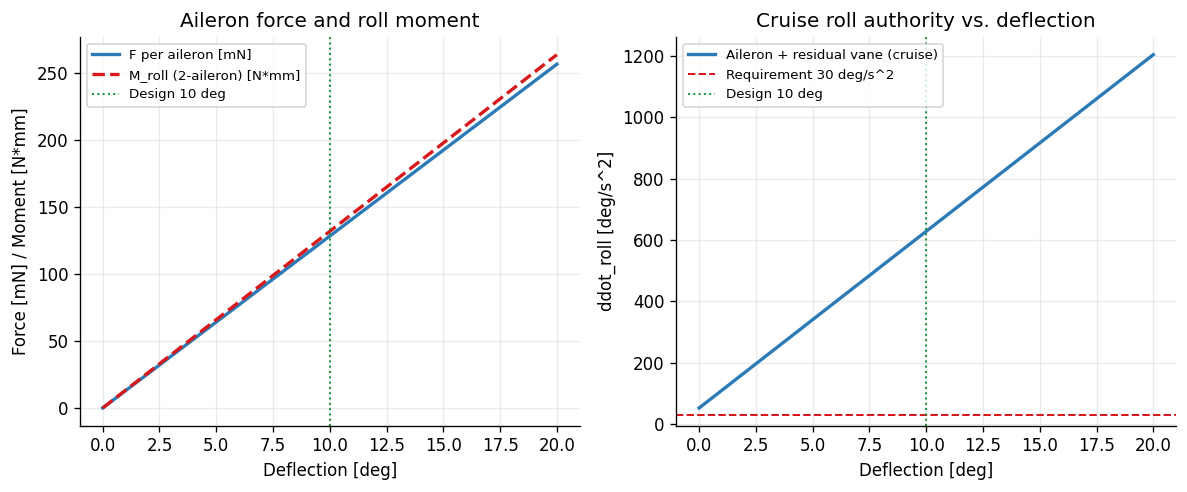

In [5]:
delta_v = np.linspace(0, ail_p.delta_max_deg, 300)
delta_r = np.radians(delta_v)

F_v       = ail.q_cruise_Pa * ail.S_aileron_m2 * ail.Cl_delta_per_rad * delta_r
M_roll_v  = 2.0 * F_v * ail.y_arm_m
ddot_v    = np.degrees(M_roll_v / vanes["I_roll_kgm2"])
ddot_combined_v = ddot_v + ddot_roll_vane_cruise

fig, axs = plt.subplots(1, 2, figsize=(10, 4.2))

axs[0].plot(delta_v, F_v * 1e3, color=C[0], lw=2, label="F per aileron [mN]")
axs[0].plot(delta_v, M_roll_v * 1e3, color=C[1], lw=2, ls="--",
            label="M_roll (2-aileron) [N*mm]")
axs[0].axvline(ail_p.delta_design_deg, ls=":", color=C[2], lw=1.2,
               label=f"Design {ail_p.delta_design_deg:.0f} deg")
axs[0].set_xlabel("Deflection [deg]")
axs[0].set_ylabel("Force [mN] / Moment [N*mm]")
axs[0].set_title("Aileron force and roll moment")
axs[0].legend(fontsize=8)

axs[1].plot(delta_v, ddot_combined_v, color=C[0], lw=2,
            label="Aileron + residual vane (cruise)")
axs[1].axhline(ddot_min, ls="--", color=C[1], lw=1.2,
               label=f"Requirement {ddot_min:.0f} deg/s^2")
axs[1].axvline(ail_p.delta_design_deg, ls=":", color=C[2], lw=1.2,
               label=f"Design {ail_p.delta_design_deg:.0f} deg")
axs[1].set_xlabel("Deflection [deg]")
axs[1].set_ylabel("ddot_roll [deg/s^2]")
axs[1].set_title("Cruise roll authority vs. deflection")
axs[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_PATH / "aileron_authority_curves.png", dpi=120, bbox_inches="tight")
plt.show()


# Section 5 — Output Export

`out/aileron.yaml` -- consumed by `fuselage_design.py` (servo/linkage mass
carve-out) and kept for reference by downstream notebooks.

---

In [6]:
write_aileron_yaml(
    ail, ail_p, OUT_PATH / "aileron.yaml",
    ddot_roll_vane_cruise_deg_s2=ddot_roll_vane_cruise,
    ddot_min_deg_s2=ddot_min,
)
print(f"Aileron design written -> {OUT_PATH / 'aileron.yaml'}")


Aileron design written -> D:\Dev\vbat-uav-notebooks\out\aileron.yaml


# Section 6 — Design Summary

---

In [7]:
bar = "=" * 60
print(bar)
print("  AILERON DESIGN SUMMARY".center(60))
print(bar)
print(f"  {'Aileron chord / span':<34}: {ail.c_aileron_m*1e3:.1f} / {ail.b_aileron_m*1e3:.1f} mm")
print(f"  {'Aileron area (1 side)':<34}: {ail.S_aileron_m2*1e4:.2f} cm^2")
print(f"  {'Flap effectiveness tau':<34}: {ail.tau:.3f}")
print()
print(f"  {'Jet-vane ddot_roll, hover':<34}: {ddot_roll_vane_hover:8.1f} deg/s^2")
print(f"  {'Jet-vane ddot_roll, cruise':<34}: {ddot_roll_vane_cruise:8.1f} deg/s^2")
print(f"  {'Aileron ddot_roll, cruise':<34}: {ail.ddot_roll_deg_s2:8.1f} deg/s^2")
print(f"  {'Combined ddot_roll, cruise':<34}: {ddot_roll_total_cruise:8.1f} deg/s^2")
print(f"  {'Requirement':<34}: {ddot_min:8.1f} deg/s^2")
print(f"  {'Cruise roll authority':<34}: {'OK' if cruise_ok else 'FAIL'}")
print()
print(f"  {'Required servo torque':<34}: >= {ail.servo_torque_req_gcm:.1f} g*cm")
print(f"  {'Servo + linkage mass (2x)':<34}: "
      f"{2*(ail_p.servo_mass_kg + ail_p.linkage_mass_kg)*1e3:.1f} g")
print(bar)


                    AILERON DESIGN SUMMARY                  
  Aileron chord / span              : 21.9 / 65.6 mm
  Aileron area (1 side)             : 14.34 cm^2
  Flap effectiveness tau            : 0.432

  Jet-vane ddot_roll, hover         :    903.6 deg/s^2
  Jet-vane ddot_roll, cruise        :     52.6 deg/s^2
  Aileron ddot_roll, cruise         :    575.7 deg/s^2
  Combined ddot_roll, cruise        :    628.3 deg/s^2
  Requirement                       :     30.0 deg/s^2
  Cruise roll authority             : OK

  Required servo torque             : >= 85.7 g*cm
  Servo + linkage mass (2x)         : 30.0 g
